In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay,classification_report

In [30]:
data = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/iris-data.csv")

In [31]:
data.head()

,sepal length,sepal width,petal length,petal width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
data.tail()

,sepal length,sepal width,petal length,petal width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [33]:
data['class'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [34]:
X = data.drop(['class'], axis=1)

In [35]:
y = data['class']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

In [37]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [38]:
y_pred = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
matrix = confusion_matrix(y_test, y_pred)

Accuracy: 0.9666666666666667
Confusion Matrix:
[[13  0  0]
 [ 0  8  0]
 [ 0  1  8]]


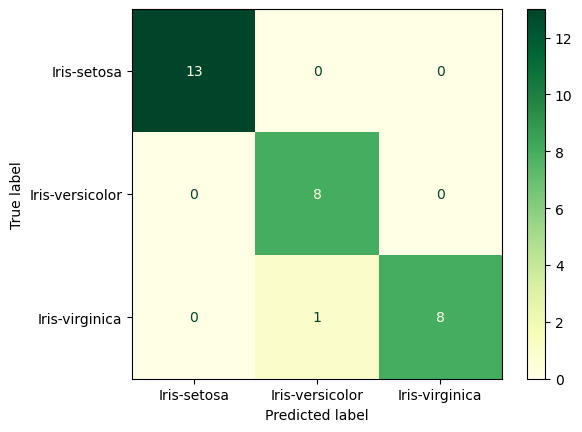

In [39]:
tp, fn, fp, tn = confusion_matrix(y_test,y_pred,labels=['Iris-setosa','Iris-virginica']).reshape(-1)
conf_matrix = ConfusionMatrixDisplay(confusion_matrix=matrix,display_labels=model.classes_)
conf_matrix.plot(cmap=plt.cm.YlGn)
plt.show()

In [40]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       0.89      1.00      0.94         8
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.96      0.96      0.96        30
   weighted avg       0.97      0.97      0.97        30



In [41]:
print('\nAccuracy: {:.2f}'.format(accuracy_score(y_test,y_pred)))
print('Error Rate: ',(fp+fn)/(tp+tn+fn+fp))
print('Sensitivity (Recall or True positive rate) :',tp/(tp+fn))
print('Specificity (True negative rate) :',tn/(fp+tn))
print('Precision (Positive predictive value) :',tp/(tp+fp))
print('False Positive Rate :',fp/(tn+fp))


Accuracy: 0.97
Error Rate:  0.0
Sensitivity (Recall or True positive rate) : 1.0
Specificity (True negative rate) : 1.0
Precision (Positive predictive value) : 1.0
False Positive Rate : 0.0
